<a href="https://colab.research.google.com/github/sherlyazkiah/PCVK/blob/main/Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Change Image Brigthness
-----------------------
Input brigthness value: 50


/tmp/ipython-input-1650369486.py:16: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


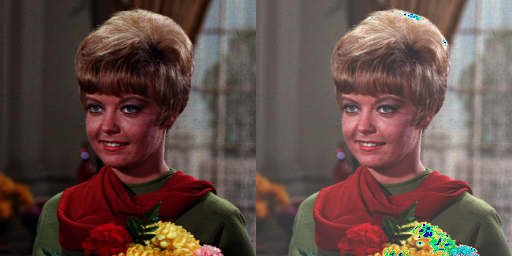

In [ ]:
from typing_extensions import final
print('Change Image Brigthness')
print('-----------------------')
try:
  brightness = int(input('Input brigthness value: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

# Access per pixel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

# Simple way without for loop
# brightness_image[y,x,c] = cv.convertScaleAbs(origial, beta=brightness)

final_frame = cv.hconcat([original, brightness_image])
cv2_imshow(final_frame)

1. Implement image inversion on Google Collaboratory using the formulas found in the
Theory Review section, resulting in the following output:

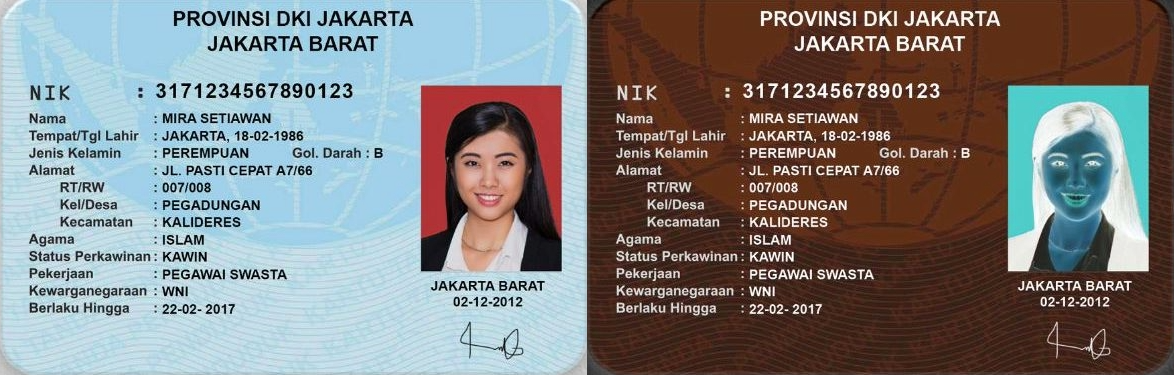

In [ ]:
ktp = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')
ktp_inversed = np.zeros(ktp.shape, ktp.dtype)

for y in range(ktp.shape[0]):
    for x in range(ktp.shape[1]):
        for c in range(ktp.shape[2]):
            ktp_inversed[y, x, c] = 255 - ktp[y, x, c]

final_ktp = cv.hconcat([ktp, ktp_inversed])
cv2_imshow(final_ktp)

2. Implement the contrast transformation in Google Collaboratory using the formula found
in the Theory Review section for contrast, resulting in the following output:

Change Image Contrast and Brigthness
------------------------------------
Input brigthness [-255 - 255]: 50
Input contrast [1.0 - 3.0]: 2


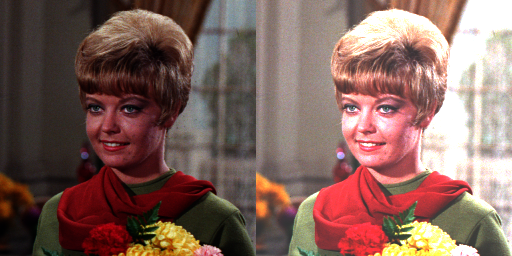

In [ ]:
from typing_extensions import final
print('Change Image Contrast and Brigthness')
print('------------------------------------')
try:
  brightness = int(input('Input brigthness [-255 - 255]: '))
  contrast = float(input('Input contrast [1.0 - 3.0]: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
contrast_image = np.zeros(original.shape, original.dtype)

# Access per pixel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      contrast_image[y,x,c] = np.clip(contrast * original[y,x,c] + brightness, 0, 255)

final_contrast = cv.hconcat([original, contrast_image])
cv2_imshow(final_contrast)

3. Implement the logarithmic brightness transformation in Google Collaboratory using the
formula found in the Theory Review section for log transformation, resulting in the
following output:

Change Image Contrast using Log Transformation
----------------------------------------------
Input constant c: 50


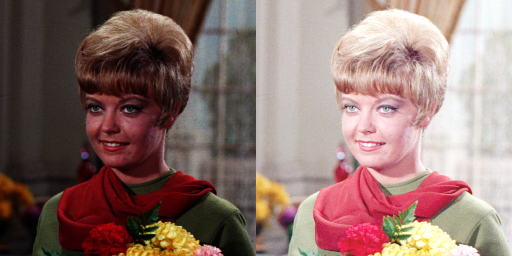

In [ ]:
print('Change Image Contrast using Log Transformation')
print('----------------------------------------------')

try:
    c = float(input('Input constant c: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')
transformed_image = np.zeros(original.shape, original.dtype)

# Access per pixel
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c_channel in range(original.shape[2]):
            # Apply log transformation to each pixel value
            # Ensure pixel values are floats before calculation
            transformed_image[y, x, c_channel] = np.clip(c * np.log(1 + original[y, x, c_channel].astype(np.float64)), 0, 255)

final_frame_log = cv.hconcat([original, transformed_image])
cv2_imshow(final_frame_log)

4. Implement the grayscale transformation using the averaging, lightness, and luminance
methods on Google Collaboratory using the formulas found in the Theory Review
section, resulting in the following output:

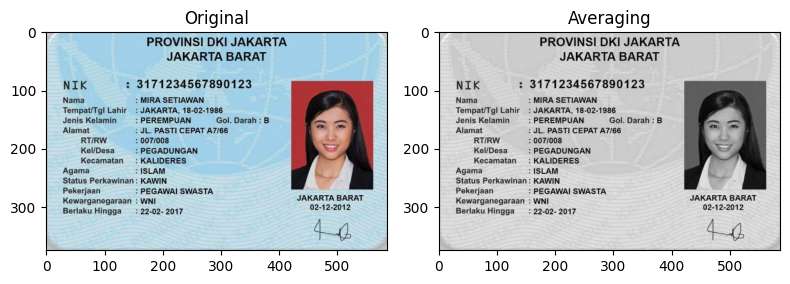

In [ ]:
ktp = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')
ktp = cv.cvtColor(ktp, cv.COLOR_BGR2RGB)

B, G, R = cv.split(ktp)

# Averaging
gray_avg = ((R.astype(np.float32) + G.astype(np.float32) + B.astype(np.float32)) / 3).astype(np.uint8)

# Show the result
plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(ktp)
plt.title("Original")
plt.axis()

plt.subplot(1, 2, 2)
plt.imshow(gray_avg, cmap="gray")
plt.title("Averaging")
plt.axis()

plt.tight_layout()
plt.show()

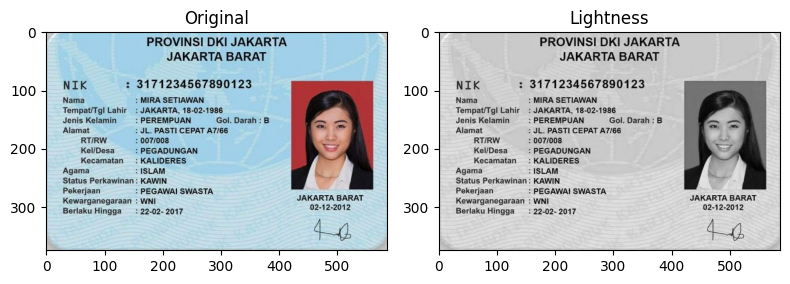

In [ ]:
ktp = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')
ktp = cv.cvtColor(ktp, cv.COLOR_BGR2RGB)

B, G, R = cv.split(ktp)

# Lightness
gray_lightness = ((np.maximum(np.maximum(R, G), B).astype(np.float32) +
                   np.minimum(np.minimum(R, G), B).astype(np.float32)) / 2).astype(np.uint8)

# Show the result
plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(ktp)
plt.title("Original")
plt.axis()

plt.subplot(1, 2, 2)
plt.imshow(gray_lightness, cmap="gray")
plt.title("Lightness")
plt.axis()

plt.tight_layout()
plt.show()

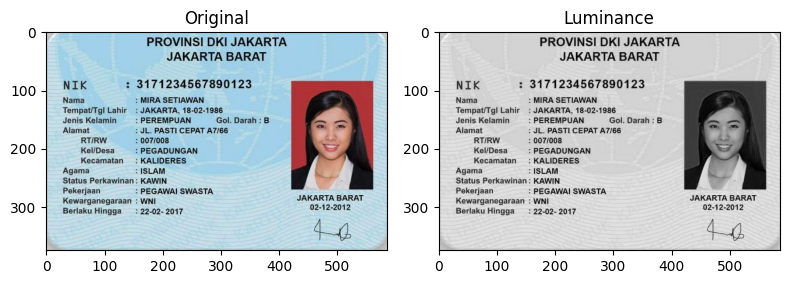

In [ ]:
ktp = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')
ktp = cv.cvtColor(ktp, cv.COLOR_BGR2RGB)

B, G, R = cv.split(ktp)

# Luminance
gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

# Show the result
plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(ktp)
plt.title("Original")
plt.axis()

plt.subplot(1, 2, 2)
plt.imshow(gray_luminance, cmap="gray")
plt.title("Luminance")
plt.axis()

plt.tight_layout()
plt.show()

5. Display certain colors in an image and convert other colors to grayscale. For example, display blue in the input image and convert other non-blue parts to grayscale, as in the following example:

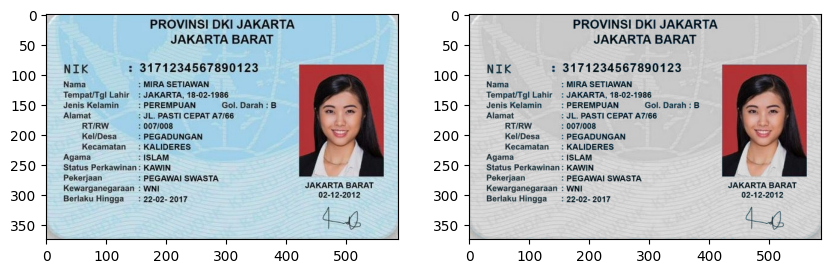

In [ ]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/ktp.jpg')
color_gray_ktp = np.zeros(original.shape, original.dtype)

for x in range(original.shape[0]):
  for y in range(original.shape[1]):
    b = int(original[x, y, 0])
    g = int(original[x, y, 1])
    r = int(original[x, y, 2])

    average_grayscale = (r+g+b)/3
    if(r < 250 and g > 0 and b > 200):
      color_gray_ktp[x, y] = average_grayscale
    else:
      color_gray_ktp[x, y] = original[x, y]

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
color_gray_rgb = cv.cvtColor(color_gray_ktp, cv.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.imshow(original_rgb)
plt.axis()

plt.subplot(1,2,2)
plt.imshow(color_gray_rgb)
plt.axis()

plt.show()

1. Make Gamma Correction according to the following instructions

 Gamma Correction pada citra 
-----------------------------
Masukkan nilai Gamma: 3


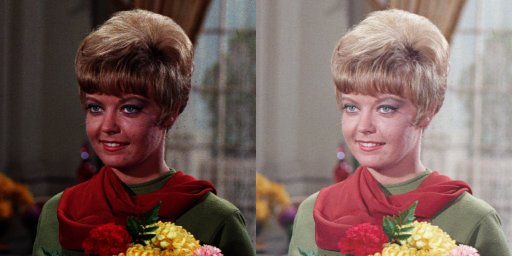

In [ ]:
print(' Gamma Correction pada citra ')
print('-----------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff')

# Normalize to range [0,1], apply gamma correction, then rescale to [0,255]
gamma_corrected = np.array(255 * ((original / 255) ** (1.0/gamma)), dtype='uint8')

final_frame_gamma = cv.hconcat([original, gamma_corrected])
cv2_imshow(final_frame_gamma)

2. Create Image Depth Simulation

(np.float64(-0.5), np.float64(511.5), np.float64(255.5), np.float64(-0.5))

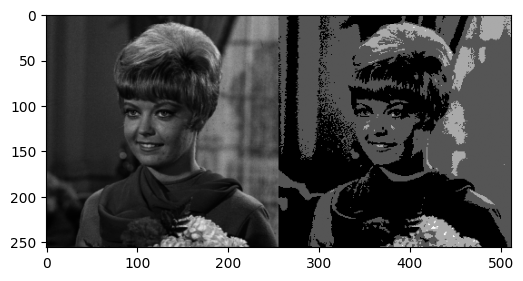

In [ ]:
bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/PCVK/Images/female.tiff',
                     cv.IMREAD_GRAYSCALE)

quantized = np.round(original / level) * level
quantized = np.uint8(quantized)

final_image = cv.hconcat([original, quantized])

plt.figure(figsize=(6,4))
plt.imshow(final_image, cmap='gray')
plt.axis()

3. Create an Average Denoising module

Total noisy images loaded: 100


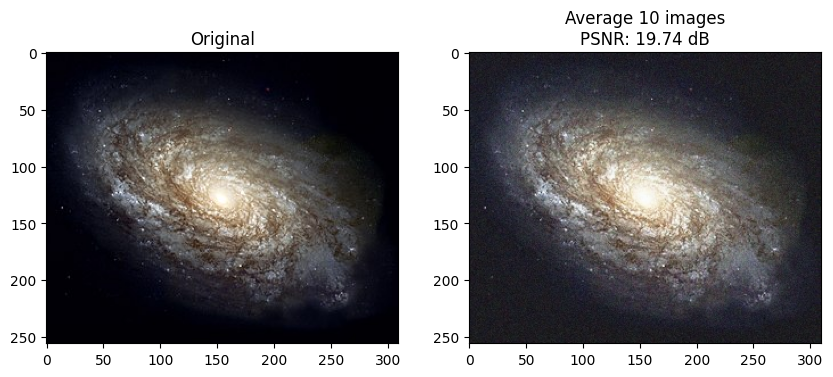

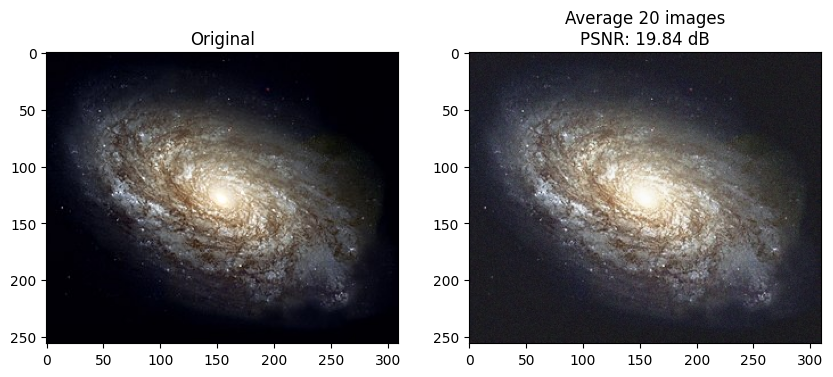

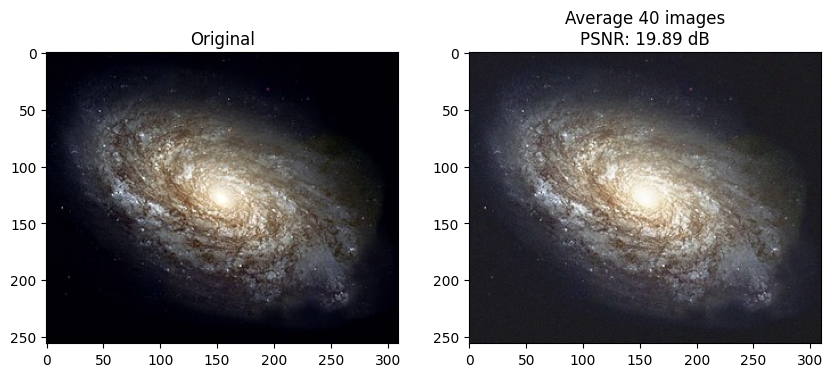

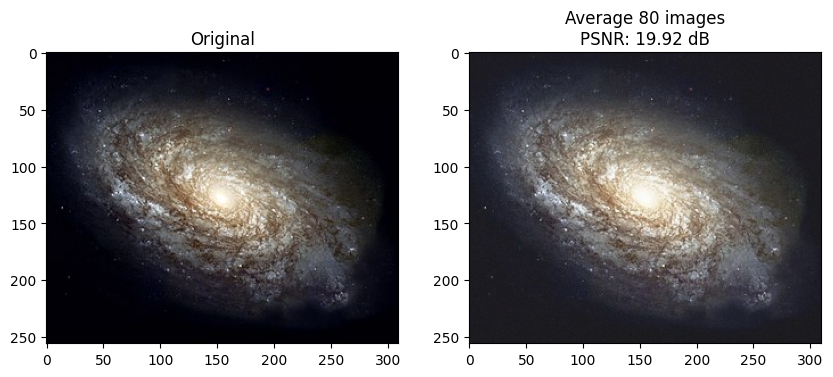

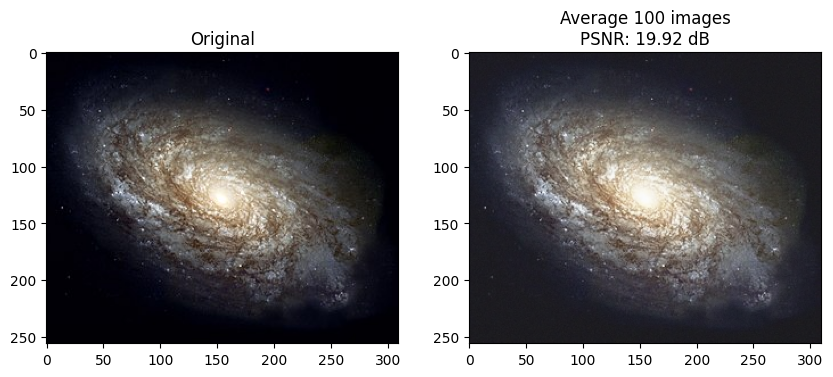

No | Number of Images | PSNR (dB)
----------------------------------
1. | 10                | 19.74
2. | 20                | 19.84
3. | 40                | 19.89
4. | 80                | 19.92
5. | 100               | 19.92


In [4]:
import math
import glob

# Load original image (RGB)
original = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Load noisy images using glob (RGB)
cv_img = []
for img in glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg'):
    n = cv.imread(img)
    n = cv.cvtColor(n, cv.COLOR_BGR2RGB)
    cv_img.append(n)

print(f"Total noisy images loaded: {len(cv_img)}")

# Function PSNR for RGB
def psnr(target, ref):
    mse = np.mean((target.astype(np.float32) - ref.astype(np.float32)) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 255.0
    psnr = 20 * math.log10(PIXEL_MAX / math.sqrt(mse))
    return psnr

# Test average denoising with different N
N_values = [10, 20, 40, 80, 100]
results = []

for N in N_values:
    avg_img = np.zeros_like(original, dtype=np.float32)

    # Take the first N images
    for i in range(N):
        avg_img += cv_img[i].astype(np.float32)

    avg_img /= N
    avg_img = np.uint8(avg_img)

    # Calculate PSNR
    psnr_value = psnr(original, avg_img)
    results.append((N, avg_img, psnr_value))

    # Display the result
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1), plt.imshow(original), plt.title('Original')
    plt.subplot(1,2,2), plt.imshow(avg_img), plt.title(f'Average {N} images\nPSNR: {psnr_value:.2f} dB')
    plt.show()

# Print results to table
print("No | Number of Images | PSNR (dB)")
print("----------------------------------")
for i, (N, _, psnr_val) in enumerate(results, start=1):
    print(f"{i}. | {N:<17} | {psnr_val:.2f}")


4. Create image masking

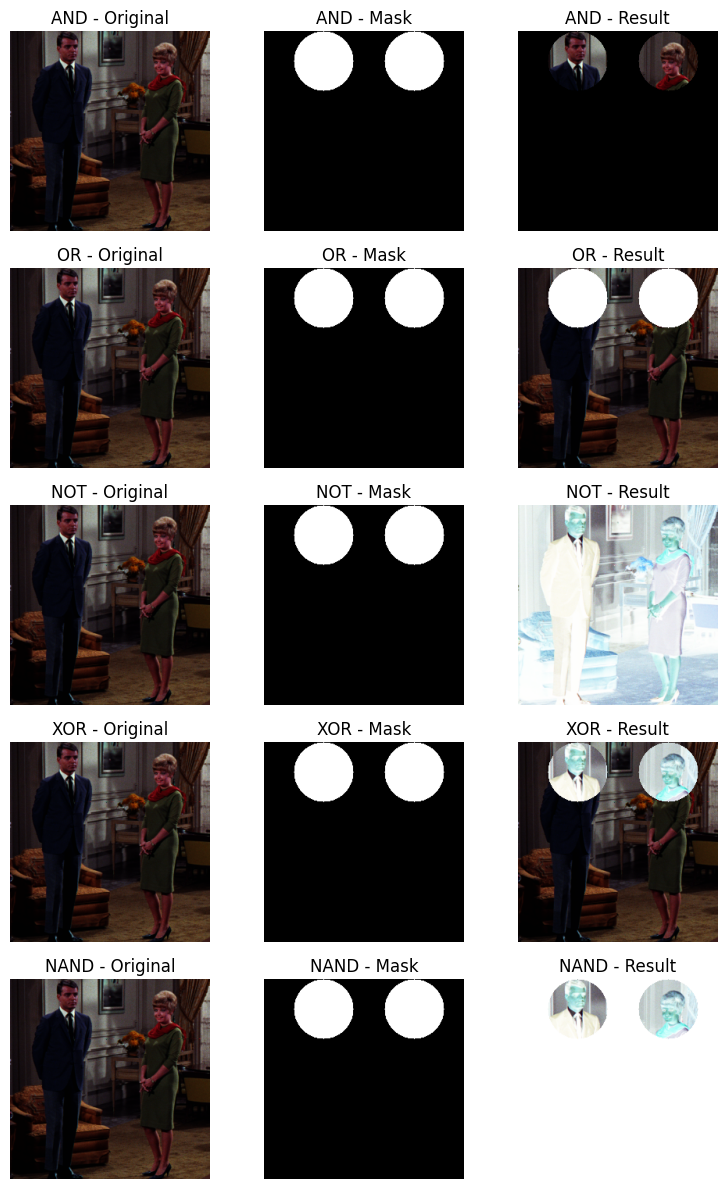

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/PCVK/Images/couple.tiff')
height, width = original.shape[:2]


# Create a circular mask
mask = np.zeros((height, width), dtype=np.uint8)

# Define circle parameters
circle1_center = (int(width * 0.3), int(height * 0.15))
circle2_center = (int(width * 0.75), int(height * 0.15))
radius = int(min(height, width) * 0.15)

# Draw white filled circles
cv.circle(mask, circle1_center, radius, 255, -1)
cv.circle(mask, circle2_center, radius, 255, -1)

# Apply different operators
mask_color = cv.merge([mask, mask, mask])  # mask 3-channel

# 1. AND
and_img = cv.bitwise_and(original, original, mask=mask)

# 2. OR
or_img = cv.bitwise_or(original, mask_color)

# 3. NOT
not_img = cv.bitwise_not(original)

# 4. XOR
xor_img = cv.bitwise_xor(original, mask_color)

# 5. NAND
nand_img = cv.bitwise_not(and_img)

# Display results (Original - Mask - Result)
operators = {
    "AND": and_img,
    "OR": or_img,
    "NOT": not_img,
    "XOR": xor_img,
    "NAND": nand_img
}

plt.figure(figsize=(8, 12))

for idx, (op_name, result) in enumerate(operators.items()):
    # Original
    plt.subplot(len(operators), 3, idx*3 + 1)
    plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
    plt.title(f"{op_name} - Original")
    plt.axis('off')

    # Mask
    plt.subplot(len(operators), 3, idx*3 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"{op_name} - Mask")
    plt.axis('off')

    # Result
    plt.subplot(len(operators), 3, idx*3 + 3)
    plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    plt.title(f"{op_name} - Result")
    plt.axis('off')

plt.tight_layout()
plt.show()